# 2D full-field sarcomere tracking

Automated tracking of every sarcomere vector across the whole image. Results are stored as dense `(n_tracks, T)` arrays in `sarc.data`.

The pipeline is **detect → sarcomere vectors → track → group → analyse**. After tracking you choose *how* to analyse the motion by **grouping** the tracks (`pool`, `mband`, `myofibril`, `loi`, `domain` or `custom`); every grouping is fed through the same contraction engine via `group_tracks(...)` → `analyze_track_motion(...)`, so the result keys and plots are identical across levels.

Details: [API reference](../autoapi/sarcasm/analysis/sarcomere_tracking/index.html).

In [1]:
from sarcasm import *
import matplotlib.pyplot as plt
import numpy as np

## Detection

Run the sarcomere U-Net on the movie (same upstream step as the structural and LOI tutorials). We also run the **3D U-Net fast-movie Z-band model** — it emits Z-band masks that are ~3× less noisy frame-to-frame than the per-frame 2D output and is used automatically by `analyze_sarcomere_vectors` when available.

In [2]:
file_path = '../../test_data/high_speed_single_ACTN2-citrine_CM/20kPa.tif'
sarc = SarcAsM(file_path, restart=False)

2026-08-01 22:44:41 - sarcasm.utils - INFO - Using device: mps


In [3]:
sarc.detect_sarcomeres()
sarc.detect_z_bands_fast_movie()  # 3D U-Net — optional but recommended for high-speed movies (potentially re-training necessary for different imaging conditions)

2026-08-01 22:44:41 - sarcasm.analysis.detection - INFO - Predicting sarcomeres ...


2026-08-01 22:44:41 - sarcasm.analysis.detection - WARNING - Pixel size (0.061 µm) is smaller than the optimal range (0.1-0.35 µm) for generalist model. Pixelsize might be too small. Consider rescale_factor=0.31 for optimal results.


2026-08-01 22:44:41 - sarcasm.analysis.detection - INFO - Using default model: /Users/daniel/Code/SarcAsM/sarcasm/models/model_sarcomeres_generalist.pt


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 1/500 [00:00<06:40,  1.24it/s]

...

 67%|██████▋   | 4/6 [00:33<00:16,  8.42s/it]

 83%|████████▎ | 5/6 [00:42<00:08,  8.39s/it]

100%|██████████| 6/6 [00:50<00:00,  8.37s/it]

100%|██████████| 6/6 [00:50<00:00,  8.41s/it]

2026-08-01 22:46:46 - sarcasm.analysis.detection - INFO - Patch (256, 208, 368), (2, 1, 3) tiles


## Sarcomere vectors

Three parameters here decide the quality of the length estimate:

- `peak_prominence` (default 0.4) — how strictly Z-band peaks are accepted inside each profile. It governs *which* vectors are admitted, not how precisely each peak is located; below ~0.4 a thin tail of grossly wrong lengths appears. Lower it if your recordings are dim.
- `linewidth` (default 0.3 µm) — the width of the profile line, averaged *along* the M-band, i.e. laterally across the myofibril. Widening it does **not** reduce frame-to-frame noise (only −16 % from 0.1 to 1.5 µm, because the noise is a coherent wobble of the whole Z-band); it raises the detection rate slightly and shifts the absolute length by ~1 % in a sample-dependent direction. For less frame-to-frame noise, run `detect_z_bands_fast_movie` (the 3D U-Net) rather than widening this.
- `smooth_orientation_sigma` — an axially-correct temporal Gaussian on the orientation field, in frames. High-speed movies only; leave at 0 for long-term time-lapses, where consecutive frames show different structures.

`use_fast_movie_zbands=True` (the default) uses the `zbands_fast_movie` mask from the OME-Zarr store when it exists. The log line printed by this cell tells you which Z-band source was used; set `use_fast_movie_zbands=False` to force the per-frame 2D masks if the 3D model is unreliable on a given movie.

In [4]:
sarc.analyze_sarcomere_vectors(
    smooth_orientation_sigma=1,
)

2026-08-01 22:46:49 - sarcasm.structure - INFO - Temporally smoothing orientation field with sigma=1.000 frames...


2026-08-01 22:46:56 - sarcasm.structure - INFO - Starting sarcomere length and orientation analysis...


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 1/500 [00:00<05:23,  1.54it/s]

  1%|          | 3/500 [00:00<02:04,  3.99it/s]

...

 99%|█████████▊| 493/500 [00:46<00:00, 10.59it/s]

 99%|█████████▉| 495/500 [00:46<00:00, 10.57it/s]

 99%|█████████▉| 497/500 [00:47<00:00, 10.56it/s]

100%|█████████▉| 499/500 [00:47<00:00, 10.65it/s]

100%|██████████| 500/500 [00:47<00:00, 10.56it/s]

## 2D tracker

Every sarcomere vector of the first frame seeds a **query point**. In each following frame the query points are matched to that frame's detections by an exact minimum-cost assignment, solved per connected component of the candidate graph; detections that no query point claims start a new track. The tracker reads no pixels and needs no optical flow — a query point that misses a frame is carried by the coherent motion of its neighbours, and because each detection is consumed at most once, two tracks can never collapse onto the same sarcomere.

Three gates decide what may match, all in physical units so they hold at any pixel size: `max_disp_along_um` (1.0 µm, along the sarcomere axis), `max_disp_perp_um` (0.2 µm, sideways — a perpendicular jump is a swap onto a neighbouring myofibril) and `ori_tol_deg` (45°). A query point with no consistent detection records an honest gap frame (`tracks_observed` False, length NaN) and keeps its identity, so a dropout of any length no longer ends a trajectory; interior gaps of at most `max_gap_interpolation_s` seconds get their length interpolated for plotting, but never count as observations. Tracks therefore do not retire by default (`retire_after_s=None`) — set it for long recordings where sarcomeres genuinely come and go.

The log line reports the **fragmentation ratio**, tracks per detection per frame: 1.0 means one track per sarcomere for the whole movie. See the docstring for all parameters.

In [5]:
sarc.track_sarcomere_vectors()

2026-08-01 22:47:44 - sarcasm.structure - INFO - Tracking 500 frames...


2026-08-01 22:47:44 - sarcasm.analysis.sarcomere_tracking - INFO - Tracking: min_track_duration=0.08 s (5 observations), retire_after=None s (frametime=0.01640603505074978).


2026-08-01 22:47:44 - sarcasm.analysis.sarcomere_tracking - INFO - Seeding query points from frame 0…


2026-08-01 22:47:44 - sarcasm.analysis.sarcomere_tracking - INFO - Tracking frames…


2026-08-01 22:48:00 - sarcasm.analysis.sarcomere_tracking - INFO - Filtering short tracks…


2026-08-01 22:48:00 - sarcasm.analysis.sarcomere_tracking - INFO - Interpolated sarcomere length / orientation on 111668 gap frames (gaps of at most 3 frames); 'motion.tracks.observed' stays False there, so no coverage metric counts them.


2026-08-01 22:48:00 - sarcasm.analysis.sarcomere_tracking - INFO - 5259 tracks for ~4164 detections/frame (fragmentation ratio 1.26, ideal 1.0).


2026-08-01 22:48:00 - sarcasm.analysis.sarcomere_tracking - INFO - 4/5259 tracks drift more than one sarcomere length away from their neighbours (see 'motion.tracks.drift_um'); chain groupings (myofibril/loi) drop them by default.


2026-08-01 22:48:00 - sarcasm.structure - INFO - Tracked 5259 sarcomere query points over 500 frames.


## Tracking output

The tracker writes dense, row-aligned arrays into `sarc.data` — one row per track, one column per frame:

| key | shape | meaning |
|---|---|---|
| `tracks_slen` | `(n_tracks, T)` | sarcomere length in µm; NaN on gap frames |
| `tracks_orientations` | `(n_tracks, T)` | sarcomere angle in rad (modulo π) |
| `tracks_positions_um`, `tracks_positions_px` | `(n_tracks, T, 2)` | sarcomere-centre position `(y, x)` |
| `tracks_observed` | `(n_tracks, T)` | True where the frame is a real detection, not a gap |
| `tracks_midline_id`, `tracks_detection_id` | `(n_tracks, T)` | which M-band / which per-frame detection was matched |
| `track_ids`, `track_start_frame`, `track_lengths`, `track_drift_um` | `(n_tracks,)` | per-track summary |

`sarc.get_tracks()` returns that per-track summary as a tidy DataFrame.

A key is its path: `sarc.data['motion.tracks.slen']` and `sarc.data.motion.tracks.slen` are the same array. Results live in three namespaces — `structure.*` (per-frame morphology), `motion.*` (everything derived from the tracks) and `params.*` (what each step ran with) — so `sarc.data.structure.sarcomere.oop` and `sarc.data.params.track_sarcomere_vectors.frames` read the same way. `sarc.data.handle('motion.tracks.slen')` gives a lazy Zarr handle when you want one row without loading the block.

To find your way around: `print(sarc)` summarises the object, `sarc.data` lists what is in the store, `sarc.data.find('slen')` searches the keys, `sarc.data.describe('motion.tracks.slen')` explains one, and `sarc.data.<TAB>` completes the namespaces.


In [6]:
slen = np.asarray(sarc.data['motion.tracks.slen'])                     # (n_tracks, T), NaN on gap frames
pos = np.asarray(sarc.data['motion.tracks.positions_um'])              # (n_tracks, T, 2), (y, x) in µm
observed = np.asarray(sarc.data['motion.tracks.observed']).astype(bool)  # real detection vs gap
T = slen.shape[1]
time_s = np.arange(T) * sarc.metadata.frametime
print(f'{slen.shape[0]} tracks x {T} frames; '
      f'{100 * observed.mean():.0f}% of all track-frames are observations; '
      f'fragmentation ratio {float(sarc.data["fragmentation_ratio"]):.2f}')

5259 tracks x 500 frames; 78% of all track-frames are observations; fragmentation ratio 1.26


### Control plot — track completeness

The first thing to look at after a tracking run: **how complete is each track?** The measure is the percentage of the recording's frames in which the track was matched to a real detection (`track_lengths / T`), so 100 % means that sarcomere was observed in every single frame. Interpolated gap frames do not count.

Two views of that one number, and they answer different questions:

- `plot_track_coverage_map` — every trajectory drawn over the inverted raw image, coloured by its completeness. Shows **where** the tracking is complete and where it breaks down (typically the cell edges and out-of-focus regions).
- `plot_track_coverage_histogram` — the distribution over all tracks. Shows **how much** of the field tracks well. A dominant peak at 100 % is what a healthy run looks like; a heavy left tail means fragmentation (cross-check `fragmentation_ratio`).

The bars are filled from the same colormap over the same 0–100 % range as the map, so the colorbar is the legend for both panels.

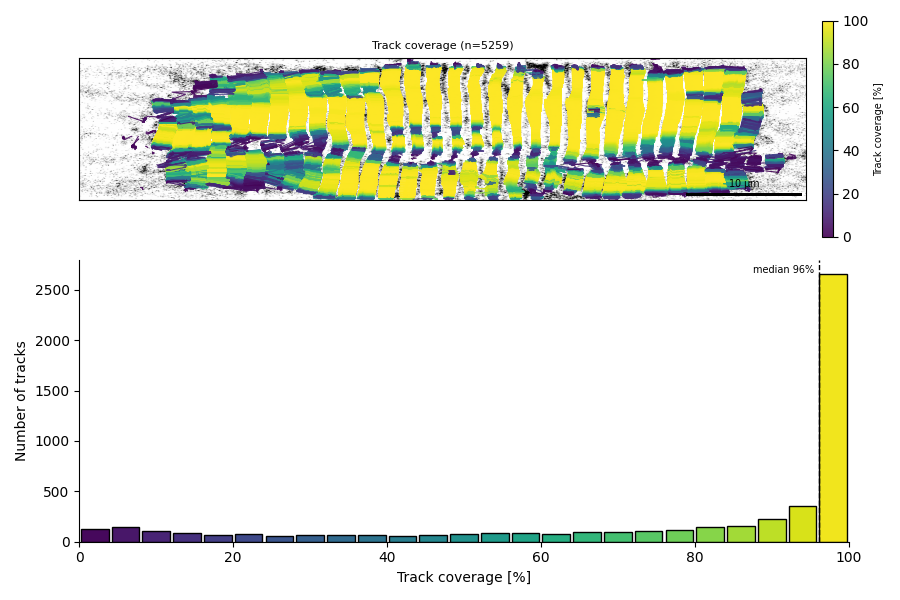

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), height_ratios=[1, 1.3])
Plots.plot_track_coverage_map(axes[0], sarc)         # where the complete tracks are
Plots.plot_track_coverage_histogram(axes[1], sarc)   # how complete they are
plt.tight_layout()
plt.show()

### Sample individual trajectories

Nine tracks drawn at random from **all** tracks — no coverage filter, so short fragments and gap frames (NaN, drawn as breaks in the line) appear as they are.

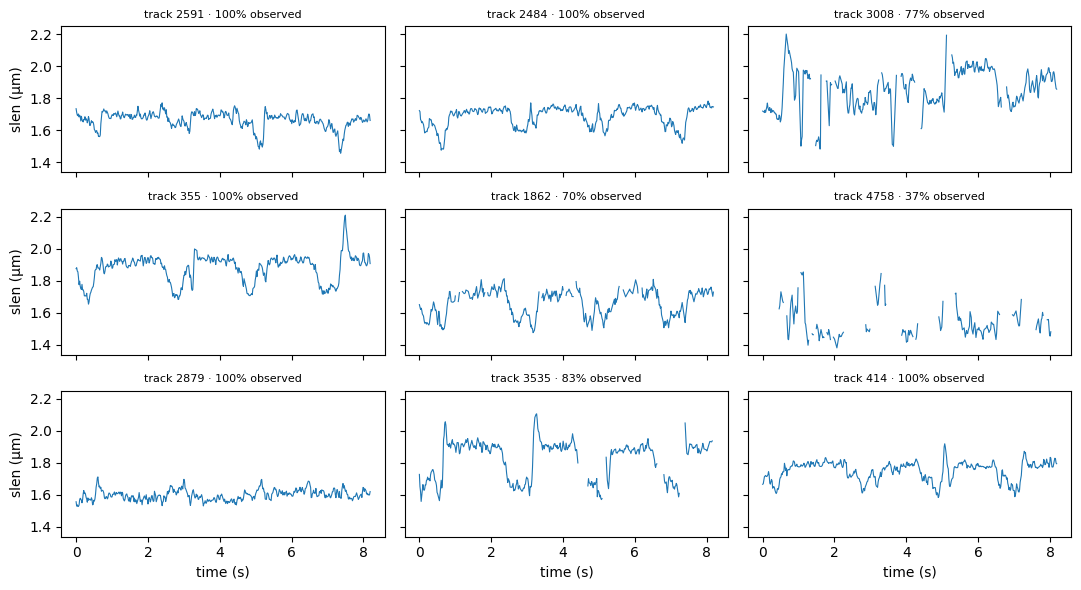

In [8]:
rng = np.random.default_rng(31)
picks = rng.choice(slen.shape[0], 9, replace=False)
fig, axes = plt.subplots(3, 3, figsize=(11, 6), sharex=True, sharey=True)
for ax, i in zip(axes.flat, picks):
    ax.plot(time_s, slen[i], lw=0.8)
    ax.set_title(f'track {int(sarc.data["track_ids"][i])} · {100 * observed[i].mean():.0f}% observed', fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel('time (s)')
for ax in axes[:, 0]:
    ax.set_ylabel('slen (µm)')
plt.tight_layout(); plt.show()

### Ensemble sarcomere length

Mean ± SD over **all** tracks at every frame — the whole-cell beating signal straight from the raw arrays, without any grouping. `analyze_track_motion(by='pool')` below produces the same signal properly: a robust median over eligible tracks, plus contraction detection and per-cycle metrics.

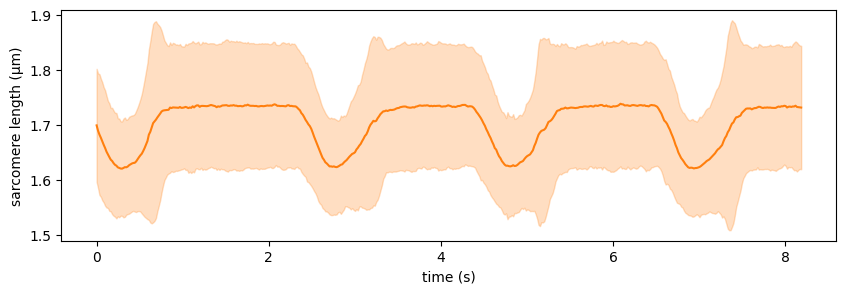

In [9]:
mean = np.nanmean(slen, axis=0)
std = np.nanstd(slen, axis=0)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(time_s, mean, color='C1')
ax.fill_between(time_s, mean - std, mean + std, alpha=0.25, color='C1')
ax.set_xlabel('time (s)'); ax.set_ylabel('sarcomere length (µm)')
plt.show()

## Motion analysis — group the tracks, then analyze

A grouping turns thousands of individual trajectories into a handful of signals. `group_tracks(by=...)` only writes label arrays — it is cheap, inspectable and freely re-callable; `analyze_track_motion()` then aggregates each group's `slen(t)` and runs the shared ContractionNet engine on it. Passing `by=` straight to `analyze_track_motion` does both in one call.

Results are written under a `<kind>_*` prefix (`pool_beating_rate`, `mband_slen_timeseries`, `domain_contr`, …), so the same plotting functions serve every level. Two filters decide what survives: `min_coverage` drops individual tracks observed in too few frames, and `min_group_size` drops whole groups with too few member tracks (their group mean would be too noisy to analyse).

| level | `by=` | one group is … | prerequisite |
|---|---|---|---|
| **(1) pool** | `'pool'` | the whole cell | — |
| **(2) M-band** | `'mband'` | the sarcomeres sharing one M-band | — |
| **(3) myofibril** | `'myofibril'` | one fibre, ordered head-to-tail | `analyze_myofibrils` |
| **(4) LOI** | `'loi'` | one curated fibre line | `detect_lois` |
| **(5) domain** | `'domain'` | one Leiden domain | `analyze_sarcomere_domains` |
| **(6) custom** | `'custom'` | whatever your labels say | `labels=` |

The chain levels (3) and (4) additionally *order* their members along the fibre, which is what lets `get_track_motion(group)` hand back a `Motion` object so every existing LOI plot applies.

### (1) Pool level — whole-cell ensemble beating

All eligible tracks form a single group, so the result is one whole-cell signal. Zero-config and a safe first call: it needs nothing but the tracks themselves.

In [10]:
# zero-config, a safe first call
sarc.analyze_track_motion(by='pool')   # all tracks with coverage >= 0.5 -> one signal
print('cell beating rate [Hz]:', sarc.data['motion.pool.beating_rate'][0])

# --- QC: how much of the detected signal actually backs that pool trace? ---
n_assigned = int((sarc.data['motion.tracks.group_id'] >= 0).sum())
n_tracks   = int(sarc.data['motion.tracks.n'])
n_vec_long = sarc.data['motion.groups.n_vectors_in_long_tracks']
n_vec_tot  = sarc.data['motion.groups.n_vectors_total']
print(f'tracks assigned to the pool:           {n_assigned}/{n_tracks} '
      f'({100 * n_assigned / n_tracks:.0f}%)')
print(f'sarcomere-vector obs. in a long track: {n_vec_long}/{n_vec_tot} '
      f'({100 * n_vec_long / n_vec_tot:.0f}%)')
# The track count is dominated by many short fragments, so it looks low; weighting by
# sarcomere-vector observations shows most of the real signal is captured by long tracks.

2026-08-01 22:48:01 - sarcasm.structure - INFO - group_tracks(by='pool'): 1 groups, 4229/5259 tracks assigned.


2026-08-01 22:48:01 - sarcasm.structure - INFO - analyze_track_motion: 1 'pool' groups...


2026-08-01 22:48:01 - sarcasm.analysis.contraction_analysis - INFO - 1/4 contraction cycles are incomplete (within 3 frames of the recording start/end); they are kept in the contraction mask but their duration-dependent metrics are NaN.


2026-08-01 22:48:01 - sarcasm.structure - INFO - analyze_track_motion complete ('pool', 1 groups).


cell beating rate [Hz]: 0.4606033718443715
tracks assigned to the pool:           4229/5259 (80%)
sarcomere-vector obs. in a long track: 1943051/2051306 (95%)


**Four views of the grouped motion.** The same `<kind>_*` results drive four plotting functions — two granularities × two quantities:

|  | sarcomere length (SL) | length change (ΔSL) |
|---|---|---|
| **per-group mean** (one stacked row per group) | `plot_slen_mean` | `plot_delta_slen_mean` |
| **individual sarcomeres + mean** (one group) | `plot_slen` | `plot_delta_slen` |

`plot_slen` / `plot_delta_slen` overlay every member sarcomere of one `group` (subsampled to `max_lines`, longest-coverage first) with the group mean drawn bold. ΔSL is taken relative to each trace's equilibrium length — its median over the **non-contracting** frames (the contraction intervals come from ContractionNet). These two also accept a `Motion` (LOI) object and fall back to the per-LOI view.

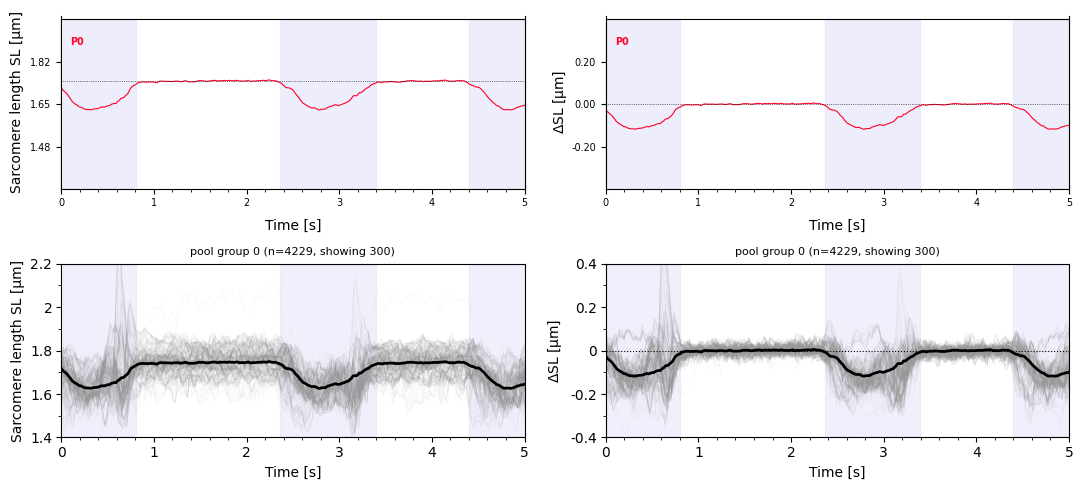

In [11]:
# pool is a single group (group=0); the identical calls work per-group for mband / domain / myofibril
fig, axes = plt.subplots(2, 2, figsize=(11, 5))
Plots.plot_slen_mean(axes[0, 0], sarc, kind='pool', t_lim=(0, 5))            # per-group mean SL
Plots.plot_delta_slen_mean(axes[0, 1], sarc, kind='pool', t_lim=(0, 5))      # per-group mean ΔSL
Plots.plot_slen(axes[1, 0], sarc, group=0, kind='pool', t_lim=(0, 5))        # member sarcomeres + mean SL
Plots.plot_delta_slen(axes[1, 1], sarc, group=0, kind='pool', t_lim=(0, 5))  # member sarcomeres + mean ΔSL
plt.tight_layout()
plt.show()

### (2) M-band level — sarcomeres sharing one M-band

Tracks matched to the same M-band (midline) at the reference frame form one group — the laterally-registered sarcomeres of a fibre bundle, contracting in step.

Because `group_tracks` runs no contraction analysis, you can QC the partition — and see which tracks were dropped by `min_coverage` — *before* paying for the analysis: `get_tracks()` returns the tidy per-track table (now with `group_id`), and `plot_track_groups` colours each tracked centre by its group, dropped tracks in grey.

2026-08-01 22:48:02 - sarcasm.structure - INFO - group_tracks(by='mband'): 61 groups, 3792/5259 tracks assigned.


,track_id,start_frame,length,n_frames,coverage,mean_slen,std_slen,drift_um,start_y_um,start_x_um,ref_midline_id,group_id,order_in_group
0,0,0,137,500,0.274,1.695760,0.064869,NaN,0.489357,37.864029,1,-1,0
1,1,0,197,500,0.394,1.676579,0.065132,0.244679,0.550527,37.864029,1,-1,0
2,2,0,206,500,0.412,1.673987,0.065908,0.305848,0.611697,37.864029,1,-1,0
3,3,0,242,500,0.484,1.655095,0.078461,NaN,0.672866,37.864029,1,-1,0
4,4,0,261,500,0.522,1.638638,0.081041,NaN,0.734036,37.925198,1,0,0


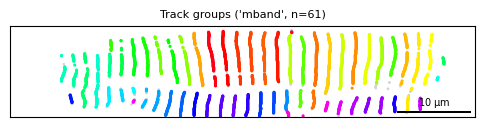

In [12]:
# group cheaply, inspect, then analyse
sarc.group_tracks(by='mband', reference_frame=0)
display(sarc.get_tracks().head())

fig, ax = plt.subplots(figsize=(6, 6))
Plots.plot_track_groups(ax, sarc, frame=0)
plt.show()

2026-08-01 22:48:02 - sarcasm.structure - INFO - group_tracks(by='mband'): 61 groups, 3792/5259 tracks assigned.


2026-08-01 22:48:04 - sarcasm.structure - INFO - analyze_track_motion: 61 'mband' groups...


2026-08-01 22:48:04 - sarcasm.analysis.contraction_analysis - WARNING - M-band 32: Only 1 contraction cycle(s) detected. Cannot compute beating rate (requires >= 2 cycles).


2026-08-01 22:48:05 - sarcasm.analysis.contraction_analysis - INFO - 28/254 contraction cycles are incomplete (within 3 frames of the recording start/end); they are kept in the contraction mask but their duration-dependent metrics are NaN.


2026-08-01 22:48:05 - sarcasm.structure - INFO - analyze_track_motion complete ('mband', 61 groups).


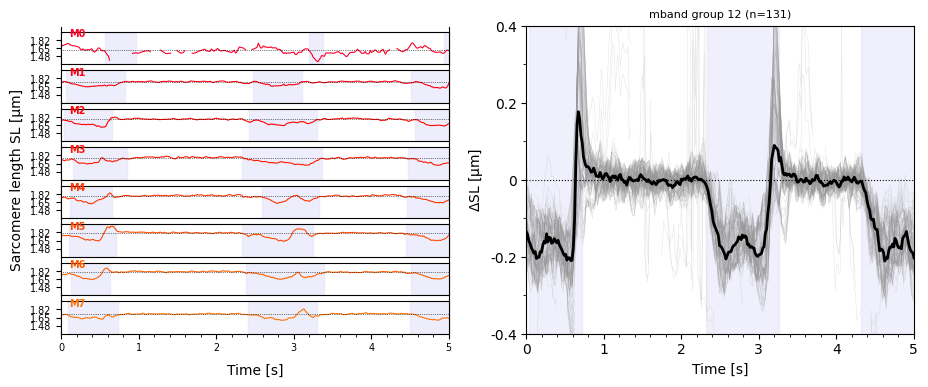

In [13]:
sarc.analyze_track_motion(by='mband', reference_frame=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
Plots.plot_slen_mean(axes[0], sarc, kind='mband', t_lim=(0, 5), n_rows=8)   # first 8 M-bands
Plots.plot_delta_slen(axes[1], sarc, group=12, kind='mband', t_lim=(0, 5))  # members of one M-band + mean
plt.show()

### (3) Myofibril level — automatic LOI-equivalent

Tracks are ordered into fibre chains from the myofibril lines (needs `analyze_myofibrils`). `analyze_track_motion(by='myofibril')` gives the per-fibre time-series, while `plot_track_myofibrils` draws each fibre as a connected polyline over the image (the spatial overlay). For the full LOI analysis, `get_track_motion(group)` returns a `Motion` view of one fibre, so **every existing LOI plot** works on a tracker-derived myofibril.

A fine grouping like this produces many 1–5 sarcomere fragments, so `min_group_size` is worth setting: it drops chains with too few tracked sarcomeres to give a usable group mean. The cell below prints how many fibres survive.

2026-08-01 22:48:05 - sarcasm.structure - INFO - Starting myofibril line analysis...


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:03<00:00,  3.29s/it]

100%|██████████| 1/1 [00:03<00:00,  3.29s/it]

2026-08-01 22:48:09 - sarcasm.structure - INFO - max_drift_slen=1.0: dropped 4 track(s) drifting >1.71 µm from their neighbours before building the myofibril chains.


...

2026-08-01 22:48:09 - sarcasm.structure - INFO - group_tracks(by='myofibril'): 51 groups, 858/5259 tracks assigned.


2026-08-01 22:48:10 - sarcasm.structure - INFO - analyze_track_motion: 51 'myofibril' groups...


2026-08-01 22:48:11 - sarcasm.analysis.contraction_analysis - INFO - 34/205 contraction cycles are incomplete (within 3 frames of the recording start/end); they are kept in the contraction mask but their duration-dependent metrics are NaN.


2026-08-01 22:48:11 - sarcasm.structure - INFO - analyze_track_motion complete ('myofibril', 51 groups).


fibres analysed: 51


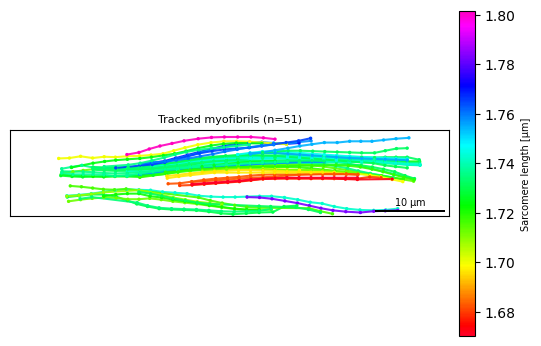

In [14]:
sarc.analyze_myofibrils(frames=[0], ratio_seeds=0.5)
# min_group_size -> skip the short fibre fragments
sarc.analyze_track_motion(by='myofibril', reference_frame=0, min_group_size=12)
print('fibres analysed:', sarc.data['motion.groups.n'])

# spatial overlay: each fibre is a polyline, coloured by its sarcomere length
fig, ax = plt.subplots(figsize=(6, 6))
Plots.plot_track_myofibrils(ax, sarc, frame=0, color_by='slen', colorbar=True)
plt.show()

2026-08-01 22:48:11 - sarcasm.utils - INFO - Using device: mps


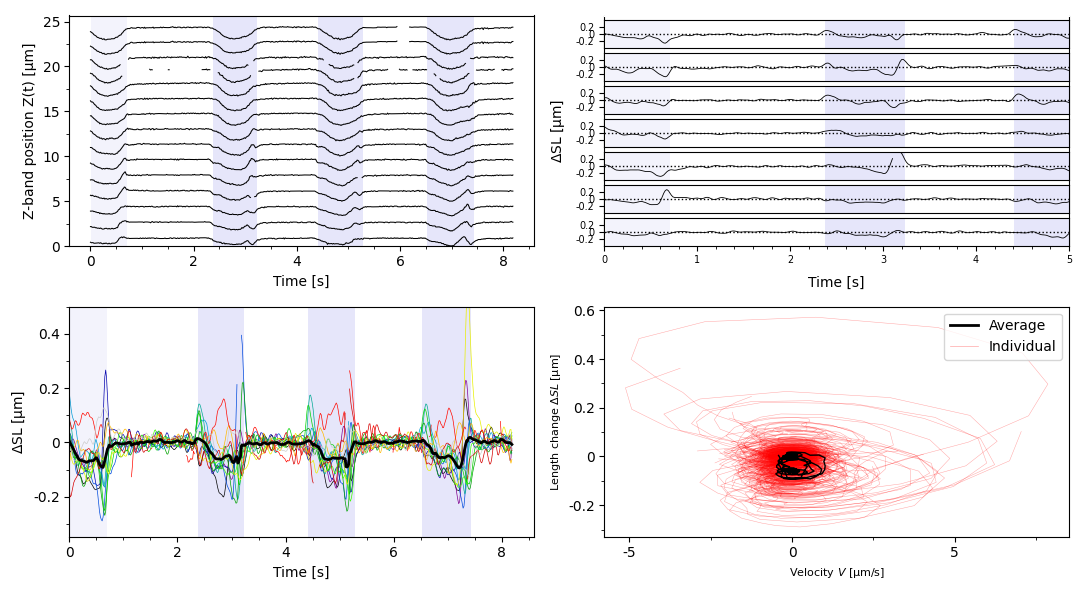

In [15]:
# rich per-fibre LOI analysis — reuse the existing Motion plots on a tracked fibre
m = sarc.get_track_motion(group=1, analyze=True)
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
Plots.plot_z_pos(axes[0, 0], m)                                 # Z-band trajectories along the fibre
Plots.plot_delta_slen(axes[0, 1], m, t_lim=(0, 5), n_rows=7)    # per-sarcomere ΔSL, stacked
Plots.plot_overlay_delta_slen(axes[1, 0], m)                    # all contractions overlaid
Plots.plot_phase_space(axes[1, 1], m)                           # ΔSL vs. velocity
plt.tight_layout()
plt.show()

### (4) LOI level — curated fibre lines (auto-detected or hand-drawn)

The **LOI** grouping is the same per-fibre engine as the myofibril method above, but instead of analysing *every* fibre it restricts to a handful of **curated lines** — handy when you care about specific fibres. `detect_lois` grows, filters and clusters candidate sarcomere lines and keeps the best `n_lois`; `group_tracks(by='loi')` then assigns each track to the nearest line and orders it along that line, so `analyze_track_motion(by='loi')` and `get_track_motion(group)` behave exactly as for `myofibril` — **every existing LOI / `Motion` plot applies**.

In the **GUI** the same grouping lives on the *Motion* tab: pick `Group by = loi` to auto-detect, or click *"Draw LOIs on movie…"* and draw the lines yourself.

2026-08-01 22:48:38 - sarcasm.structure - INFO - detect_lois: selected 4 LOI line(s).


2026-08-01 22:48:38 - sarcasm.structure - INFO - max_drift_slen=1.0: dropped 4 track(s) drifting >1.71 µm from their neighbours before building the loi chains.


2026-08-01 22:48:38 - sarcasm.structure - INFO - group_tracks(by='loi'): 4 groups, 99/5259 tracks assigned.


2026-08-01 22:48:38 - sarcasm.structure - INFO - analyze_track_motion: 4 'loi' groups...


2026-08-01 22:48:38 - sarcasm.analysis.contraction_analysis - INFO - 4/16 contraction cycles are incomplete (within 3 frames of the recording start/end); they are kept in the contraction mask but their duration-dependent metrics are NaN.


2026-08-01 22:48:39 - sarcasm.structure - INFO - analyze_track_motion complete ('loi', 4 groups).


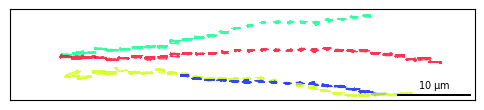

In [16]:
# analyse only a few *curated* fibre lines: the per-fibre engine of (3),
# but you pick the lines (auto-detect here, or draw them in the GUI).
sarc.detect_lois(frame=0, n_lois=4)                      # -> sarc.data['motion.loi.data']['loi_lines']
sarc.analyze_track_motion(by='loi', reference_frame=0)   # group tracks along each LOI, then analyse

# tracks-as-lines, coloured by their LOI group (trajectory view)
fig, ax = plt.subplots(figsize=(6, 6))
Plots.plot_tracks(ax, sarc, color_by='group')
plt.show()

2026-08-01 22:48:39 - sarcasm.utils - INFO - Using device: mps


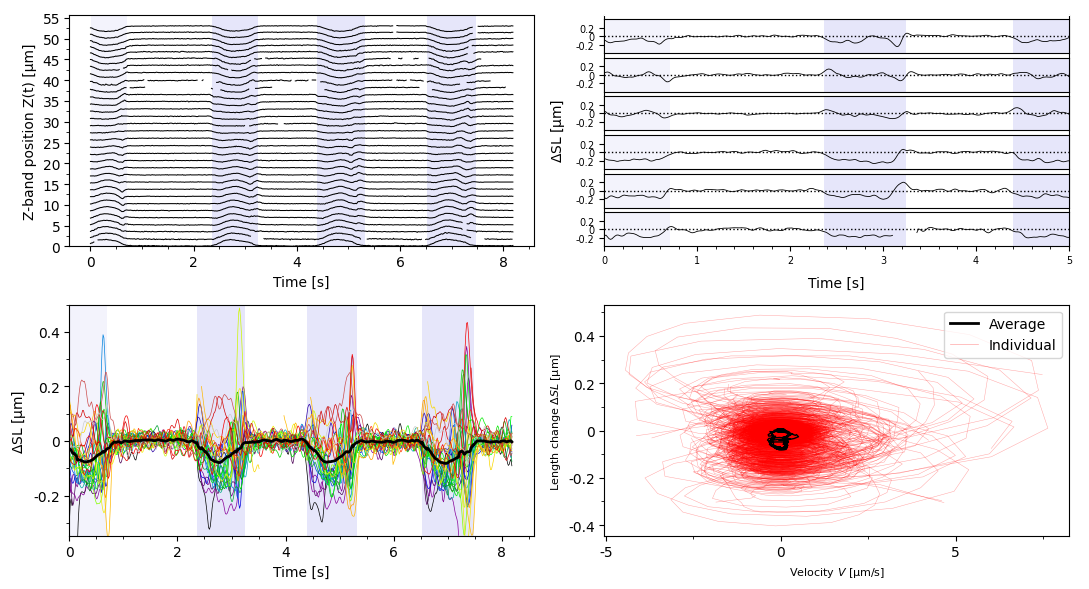

In [17]:
# rich per-LOI analysis — every existing LOI / Motion plot works on one curated line
m = sarc.get_track_motion(group=0, analyze=True)
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
Plots.plot_z_pos(axes[0, 0], m)
Plots.plot_delta_slen(axes[0, 1], m, t_lim=(0, 5))
Plots.plot_overlay_delta_slen(axes[1, 0], m)
Plots.plot_phase_space(axes[1, 1], m)
plt.tight_layout()
plt.show()

### (5) Domain level

The domain method clusters tracks into Leiden domains and writes the **same `domain_*` keys** as the old static-mask analysis, so the existing domain plots keep working unchanged. (This replaces the former `analyze_domain_motion`, which has been removed — use `analyze_track_motion(by='domain')`.)

2026-08-01 22:48:40 - sarcasm.structure - INFO - Starting sarcomere domain analysis...


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  1.49it/s]

100%|██████████| 1/1 [00:00<00:00,  1.49it/s]

2026-08-01 22:48:41 - sarcasm.structure - INFO - group_tracks(by='domain'): 5 groups, 3792/5259 tracks assigned.


2026-08-01 22:48:41 - sarcasm.structure - INFO - analyze_track_motion: 5 'domain' groups...


2026-08-01 22:48:41 - sarcasm.analysis.contraction_analysis - INFO - 5/20 contraction cycles are incomplete (within 3 frames of the recording start/end); they are kept in the contraction mask but their duration-dependent metrics are NaN.


2026-08-01 22:48:41 - sarcasm.structure - INFO - analyze_track_motion complete ('domain', 5 groups).


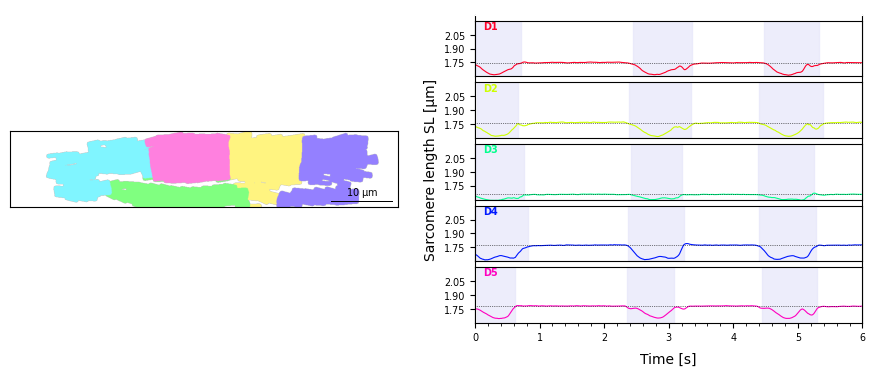

In [18]:
sarc.analyze_sarcomere_domains(frames=[0], leiden_resolution=0.5)
sarc.analyze_track_motion(by='domain', reference_frame=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
Plots.plot_sarcomere_domains(axes[0], sarc, frame=0)      # unchanged legacy plot
Plots.plot_domain_timeseries(axes[1], sarc, t_lim=(0, 6))  # unchanged legacy plot
plt.show()

### (6) Custom grouping

Supply your own integer label per track (row-aligned to `track_ids`) — e.g. from an external segmentation, a region mask, or well metadata. No new code path: `pool` / `domain` / … all run through the same engine.

In [19]:
# example: split tracks into short vs long sarcomeres
tracks = sarc.get_tracks()
labels = (tracks['mean_slen'] > tracks['mean_slen'].median()).astype(int).values
sarc.group_tracks(by='custom', labels=labels)
sarc.analyze_track_motion()
print('n custom groups:', sarc.data['motion.groups.n'])

2026-08-01 22:48:42 - sarcasm.structure - INFO - group_tracks(by='custom'): 2 groups, 4229/5259 tracks assigned.


2026-08-01 22:48:42 - sarcasm.structure - INFO - analyze_track_motion: 2 'custom' groups...


2026-08-01 22:48:42 - sarcasm.analysis.contraction_analysis - INFO - 2/8 contraction cycles are incomplete (within 3 frames of the recording start/end); they are kept in the contraction mask but their duration-dependent metrics are NaN.


2026-08-01 22:48:42 - sarcasm.structure - INFO - analyze_track_motion complete ('custom', 2 groups).


n custom groups: 2
